## Load dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
import io

uploaded = files.upload()

df = pd.read_csv(io.BytesIO(uploaded['nfl_tweets_emotions.csv']))
df.head()

Saving nfl_tweets_emotions.csv to nfl_tweets_emotions.csv


,text,hash,run_number,collected_at,clean_text,emotion,surprise,neutral,happiness,anger,sadness,fear,disgust
0,"Crazy, I was expecting them to do better this ...",1977f1e6085b2133ec36c72c70eda8b9a5006025ae6a20...,179.0,2026-04-02T13:55:48.248556,"Crazy, I was expecting them to do better this ...",surprise,0.4927,0.1657,0.1213,0.0926,0.0786,0.0397,0.0094
1,Like what did we look at over the season of cf...,36cefa490416f53b43730c23feb4bf77afe9696335bd4c...,179.0,2026-04-02T13:55:48.299718,Like what did we look at over the season of cf...,surprise,0.4284,0.5239,0.0028,0.0183,0.0108,0.0070,0.0088
2,Crazy !!! #NFL #NFLTwitter,5b2b6ff060c7c4055debfcca30258f518a270d46da1925...,179.0,2026-04-02T13:55:48.345362,Crazy !!! NFL NFLTwitter,happiness,0.1476,0.1857,0.5947,0.0489,0.0101,0.0082,0.0048
3,The NFL has to keep that race for the number o...,e43b27c6c3d68c63a82362204119323159e8ac5372d53e...,179.0,2026-04-02T13:55:48.382053,The NFL has to keep that race for the number o...,neutral,0.0067,0.9594,0.0027,0.0110,0.0072,0.0026,0.0103
4,"49ers blowing out the last-place Titans, on th...",76f2aaa78c8d60c3484fd28b5876fccde436c1b8a3c8eb...,179.0,2026-04-02T13:55:59.993439,"49ers blowing out the last-place Titans, on th...",anger,0.0662,0.4439,0.0225,0.3082,0.0625,0.0802,0.0165


In [ ]:
df.head()

,text,hash,run_number,collected_at,clean_text,emotion,surprise,neutral,happiness,anger,sadness,fear,disgust
0,"Crazy, I was expecting them to do better this ...",1977f1e6085b2133ec36c72c70eda8b9a5006025ae6a20...,179.0,2026-04-02T13:55:48.248556,"Crazy, I was expecting them to do better this ...",surprise,0.4927,0.1657,0.1213,0.0926,0.0786,0.0397,0.0094
1,Like what did we look at over the season of cf...,36cefa490416f53b43730c23feb4bf77afe9696335bd4c...,179.0,2026-04-02T13:55:48.299718,Like what did we look at over the season of cf...,surprise,0.4284,0.5239,0.0028,0.0183,0.0108,0.0070,0.0088
2,Crazy !!! #NFL #NFLTwitter,5b2b6ff060c7c4055debfcca30258f518a270d46da1925...,179.0,2026-04-02T13:55:48.345362,Crazy !!! NFL NFLTwitter,happiness,0.1476,0.1857,0.5947,0.0489,0.0101,0.0082,0.0048
3,The NFL has to keep that race for the number o...,e43b27c6c3d68c63a82362204119323159e8ac5372d53e...,179.0,2026-04-02T13:55:48.382053,The NFL has to keep that race for the number o...,neutral,0.0067,0.9594,0.0027,0.0110,0.0072,0.0026,0.0103
4,"49ers blowing out the last-place Titans, on th...",76f2aaa78c8d60c3484fd28b5876fccde436c1b8a3c8eb...,179.0,2026-04-02T13:55:59.993439,"49ers blowing out the last-place Titans, on th...",anger,0.0662,0.4439,0.0225,0.3082,0.0625,0.0802,0.0165


## Data cleaning

In [ ]:
df.shape

(6229, 13)

In [ ]:
df.describe()

,run_number,surprise,neutral,happiness,anger,sadness,fear,disgust
count,5983.000000,6229.000000,6229.000000,6229.000000,6229.000000,6229.000000,6229.000000,6229.000000
mean,519.493899,0.146479,0.552091,0.108048,0.054994,0.069314,0.029284,0.039789
std,260.620840,0.180245,0.301529,0.198133,0.130225,0.169526,0.097591,0.114622
min,179.000000,0.000600,0.001100,0.000300,0.000600,0.001000,0.000300,0.000300
25%,292.500000,0.031000,0.282600,0.006900,0.008500,0.007200,0.003500,0.003500
50%,363.000000,0.082200,0.635400,0.022500,0.015300,0.013900,0.007000,0.007000
75%,782.000000,0.186800,0.816000,0.093100,0.033300,0.035300,0.016400,0.019500
max,907.000000,0.982700,0.969600,0.990200,0.985600,0.985700,0.986600,0.979800


In [ ]:
df = df[['clean_text', 'emotion']]

In [ ]:
df.describe()

,clean_text,emotion
count,6229,6229
unique,6227,7
top,Crazy !!! NFL NFLTwitter,neutral
freq,2,2720


In [ ]:
df = df[df['emotion'] != 'neutral'] 

In [ ]:
df.describe()
df.head()

,clean_text,emotion
0,"Crazy, I was expecting them to do better this ...",surprise
1,Like what did we look at over the season of cf...,surprise
2,Crazy !!! NFL NFLTwitter,happiness
4,"49ers blowing out the last-place Titans, on th...",anger
6,Me? I’m stunned that the Chiefs are out of pla...,surprise


In [ ]:
df = df.drop_duplicates(subset=['clean_text'])  
df = df.dropna(subset=['clean_text']) 

In [ ]:
df = df.reset_index(drop=True)

In [ ]:
df.head()

,clean_text,emotion
0,"Crazy, I was expecting them to do better this ...",surprise
1,Like what did we look at over the season of cf...,surprise
2,Crazy !!! NFL NFLTwitter,happiness
3,"49ers blowing out the last-place Titans, on th...",anger
4,Me? I’m stunned that the Chiefs are out of pla...,surprise


In [ ]:
df.emotion.value_counts()

,count
emotion,
surprise,1333
happiness,938
sadness,498
anger,348
disgust,233
fear,157


## Encode labels

In [ ]:
from sklearn import preprocessing

le = preprocessing.LabelEncoder()

In [ ]:

df['emotion'] = le.fit_transform(df['emotion'])

In [ ]:
df.head()

,clean_text,emotion
0,"Crazy, I was expecting them to do better this ...",5
1,Like what did we look at over the season of cf...,5
2,Crazy !!! NFL NFLTwitter,3
3,"49ers blowing out the last-place Titans, on th...",0
4,Me? I’m stunned that the Chiefs are out of pla...,5


In [ ]:
list(le.classes_)

['anger', 'disgust', 'fear', 'happiness', 'sadness', 'surprise']

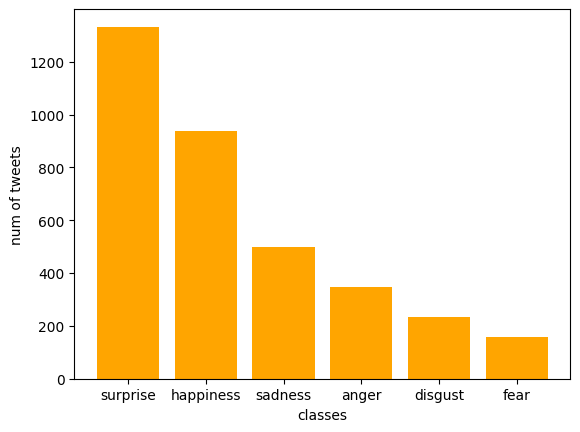

In [ ]:

classes = df.emotion.value_counts().index
num_of_objects = df.emotion.value_counts()

plt.bar(le.inverse_transform(classes), num_of_objects, color='orange')
plt.xlabel('classes')
plt.ylabel('num of tweets')
plt.show()

## Preprocess and clean text

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
wnl = WordNetLemmatizer()

In [ ]:
!pip install contractions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 13.2 MB/s eta 0:00:00


In [ ]:
import contractions

In [ ]:
stop_words = set(stopwords.words('english'))

In [ ]:
def preprocess(text):
    # delete links
    text = re.sub(r'http\S+', '', text)
    # delete hashtags
    text = re.sub(r'#\w+', '', text)
    # delete mentions
    text = re.sub(r'@\w+', '', text)
    # delete punctuation
    text = re.sub(r'[^\w\s]', '', text)
    # lowercase
    text = text.lower()
    # expand contractions
    text = contractions.fix(text)
    # tokenization
    tokens = word_tokenize(text)
    # delete stop words
    tokens = [t for t in tokens if t not in stop_words]
    # lemmatization
    lemmatized = []
    for t in tokens:
        lemma = wnl.lemmatize(t)
        lemmatized.append(lemma)
    text = ' '.join(lemmatized)
    return text

In [ ]:
df_preprocessed = df.copy()
df_preprocessed['text_processed'] = df_preprocessed['clean_text'].apply(preprocess)
df_preprocessed.head()

,clean_text,emotion,text_processed
0,"Crazy, I was expecting them to do better this ...",5,crazy expecting better year probably make cour...
1,Like what did we look at over the season of cf...,5,like look season cfb separated young men heism...
2,Crazy !!! NFL NFLTwitter,3,crazy nfl nfltwitter
3,"49ers blowing out the last-place Titans, on th...",0,49ers blowing lastplace titan verge extending ...
4,Me? I’m stunned that the Chiefs are out of pla...,5,stunned chief playoff contention panther still...


## Vectorization

TF-IDF as an example

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X = df_preprocessed['text_processed']

In [ ]:
y = df_preprocessed['emotion']

In [ ]:
"""
Full ML Pipeline: Emotion Classification on Football Tweets
X = df_preprocessed['text_processed']  (уже очищенный текст)
y = df_preprocessed['emotion']          (['anger','disgust','fear','happiness','sadness','surprise'])
"""

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from scipy.sparse import hstack

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import ComplementNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    GridSearchCV,
    train_test_split,
)
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
)
from sklearn.calibration import CalibratedClassifierCV

EMOTIONS = ['anger', 'disgust', 'fear', 'happiness', 'sadness', 'surprise']
RANDOM_STATE = 42

word_tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=20_000,
    sublinear_tf=True,      
    min_df=2,
    strip_accents="unicode",
)

char_tfidf = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    max_features=30_000,
    sublinear_tf=True,
    min_df=3,
)

In [ ]:


X = df_preprocessed['text_processed']
y = df_preprocessed['emotion']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.15,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print(f"\nClass distribution (train):\n{y_train.value_counts()}")

# Строим фичи только на train, применяем на test
X_train_word = word_tfidf.fit_transform(X_train)
X_test_word  = word_tfidf.transform(X_test)

X_train_char = char_tfidf.fit_transform(X_train)
X_test_char  = char_tfidf.transform(X_test)

X_train_feat = hstack([X_train_word, X_train_char])
X_test_feat  = hstack([X_test_word,  X_test_char])

print(f"\nFeature matrix shape: {X_train_feat.shape}")


Train: 2980 | Test: 527

Class distribution (train):
emotion
5    1133
3     797
4     423
0     296
1     198
2     133
Name: count, dtype: int64

Feature matrix shape: (2980, 28717)


In [ ]:


MODELS = {
    "Logistic Regression": LogisticRegression(
        solver="saga",
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "LinearSVC": LinearSVC(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "Complement Naive Bayes": ComplementNB(
        alpha=0.1,
    ),
    "SGD Classifier": SGDClassifier(
        loss="modified_huber",   
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}


In [ ]:


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = []
print("\n5-Fold Cross-Validation\n")

for name, model in MODELS.items():
    scores = cross_validate(
        model,
        X_train_feat,
        y_train,
        cv=cv,
        scoring={
            "f1_macro": "f1_macro",
            "f1_weighted": "f1_weighted",
            "accuracy": "accuracy",
        },
        n_jobs=-1,
    )
    row = {
        "Model": name,
        "F1-macro": scores["test_f1_macro"].mean(),
        "F1-macro std": scores["test_f1_macro"].std(),
        "F1-weighted": scores["test_f1_weighted"].mean(),
        "Accuracy": scores["test_accuracy"].mean(),
    }
    cv_results.append(row)
    print(f"{name:<30} F1-macro = {row['F1-macro']:.4f} +- {row['F1-macro std']:.4f}")

cv_df = pd.DataFrame(cv_results).sort_values("F1-macro", ascending=False)
print("\n")
print(cv_df.to_string(index=False))


=== 5-Fold Cross-Validation ===

Logistic Regression            F1-macro = 0.3962 ± 0.0245
LinearSVC                      F1-macro = 0.4321 ± 0.0263
Complement Naive Bayes         F1-macro = 0.4225 ± 0.0195
SGD Classifier                 F1-macro = 0.3875 ± 0.0255


                 Model  F1-macro  F1-macro std  F1-weighted  Accuracy
             LinearSVC  0.432147      0.026322     0.522672  0.530537
Complement Naive Bayes  0.422461      0.019487     0.510687  0.511409
   Logistic Regression  0.396154      0.024473     0.491961  0.487248
        SGD Classifier  0.387495      0.025504     0.497563  0.522148


In [ ]:
print("\nHyperparameter Tuning\n")


param_grid_lr = {
    "C":      [0.01, 0.1, 0.5, 1.0, 5.0, 10.0],
    "penalty": ["l1", "l2"],
}
gs_lr = GridSearchCV(
    LogisticRegression(solver="saga", max_iter=1000,
                       class_weight="balanced", random_state=RANDOM_STATE),
    param_grid_lr,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1,
)
gs_lr.fit(X_train_feat, y_train)
print(f"\nLogReg  best params : {gs_lr.best_params_}")
print(f"LogReg  best F1-macro: {gs_lr.best_score_:.4f}")

param_grid_svc = {
    "C": [0.01, 0.1, 0.5, 1.0, 5.0, 10.0],
}
gs_svc = GridSearchCV(
    LinearSVC(max_iter=3000, class_weight="balanced", random_state=RANDOM_STATE),
    param_grid_svc,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1,
)
gs_svc.fit(X_train_feat, y_train)
print(f"\nSVC     best params : {gs_svc.best_params_}")
print(f"SVC     best F1-macro: {gs_svc.best_score_:.4f}")

best_model = gs_svc.best_estimator_ if gs_svc.best_score_ >= gs_lr.best_score_ \
             else gs_lr.best_estimator_
best_name  = "LinearSVC" if gs_svc.best_score_ >= gs_lr.best_score_ \
             else "Logistic Regression"
print(f"\nBest overall model: {best_name}")


=== Hyperparameter Tuning ===

Fitting 5 folds for each of 12 candidates, totalling 60 fits

LogReg  best params : {'C': 5.0, 'penalty': 'l2'}
LogReg  best F1-macro: 0.4253
Fitting 5 folds for each of 6 candidates, totalling 30 fits

SVC     best params : {'C': 0.5}
SVC     best F1-macro: 0.4365

Best overall model: LinearSVC


In [ ]:

print("\nFinal Evaluation on Test Set\n")

results_test = {}
final_models = {
    "Logistic Regression (tuned)": gs_lr.best_estimator_,
    "LinearSVC (tuned)":           gs_svc.best_estimator_,
    "Complement NB":               ComplementNB(alpha=0.1),
    "SGD Classifier":              SGDClassifier(loss="modified_huber",
                                                  class_weight="balanced",
                                                  random_state=RANDOM_STATE),
}

for name, model in final_models.items():
    model.fit(X_train_feat, y_train)
    y_pred = model.predict(X_test_feat)

    results_test[name] = {
        "Accuracy":    accuracy_score(y_test, y_pred),
        "F1-macro":    f1_score(y_test, y_pred, average="macro"),
        "F1-weighted": f1_score(y_test, y_pred, average="weighted"),
        "Precision":   precision_score(y_test, y_pred, average="macro"),
        "Recall":      recall_score(y_test, y_pred, average="macro"),
    }

test_df = pd.DataFrame(results_test).T.sort_values("F1-macro", ascending=False)
print(test_df.round(4).to_string())


=== Final Evaluation on Test Set ===

                             Accuracy  F1-macro  F1-weighted  Precision  Recall
Complement NB                  0.5351    0.4551       0.5328     0.4653  0.4480
Logistic Regression (tuned)    0.5408    0.4422       0.5370     0.4524  0.4355
SGD Classifier                 0.5446    0.4272       0.5282     0.5217  0.4028
LinearSVC (tuned)              0.5294    0.4260       0.5263     0.4300  0.4231


In [ ]:

best_final = final_models[f"{best_name} (tuned)"]
y_pred_best = best_final.predict(X_test_feat)

print(f"\nClassification Report — {best_name}\n")
print(classification_report(y_test, y_pred_best, target_names=EMOTIONS))


=== Classification Report — LinearSVC ===

              precision    recall  f1-score   support

       anger       0.31      0.29      0.30        52
     disgust       0.35      0.34      0.35        35
        fear       0.21      0.17      0.19        24
   happiness       0.57      0.60      0.58       141
     sadness       0.53      0.52      0.52        75
    surprise       0.62      0.62      0.62       200

    accuracy                           0.53       527
   macro avg       0.43      0.42      0.43       527
weighted avg       0.52      0.53      0.53       527



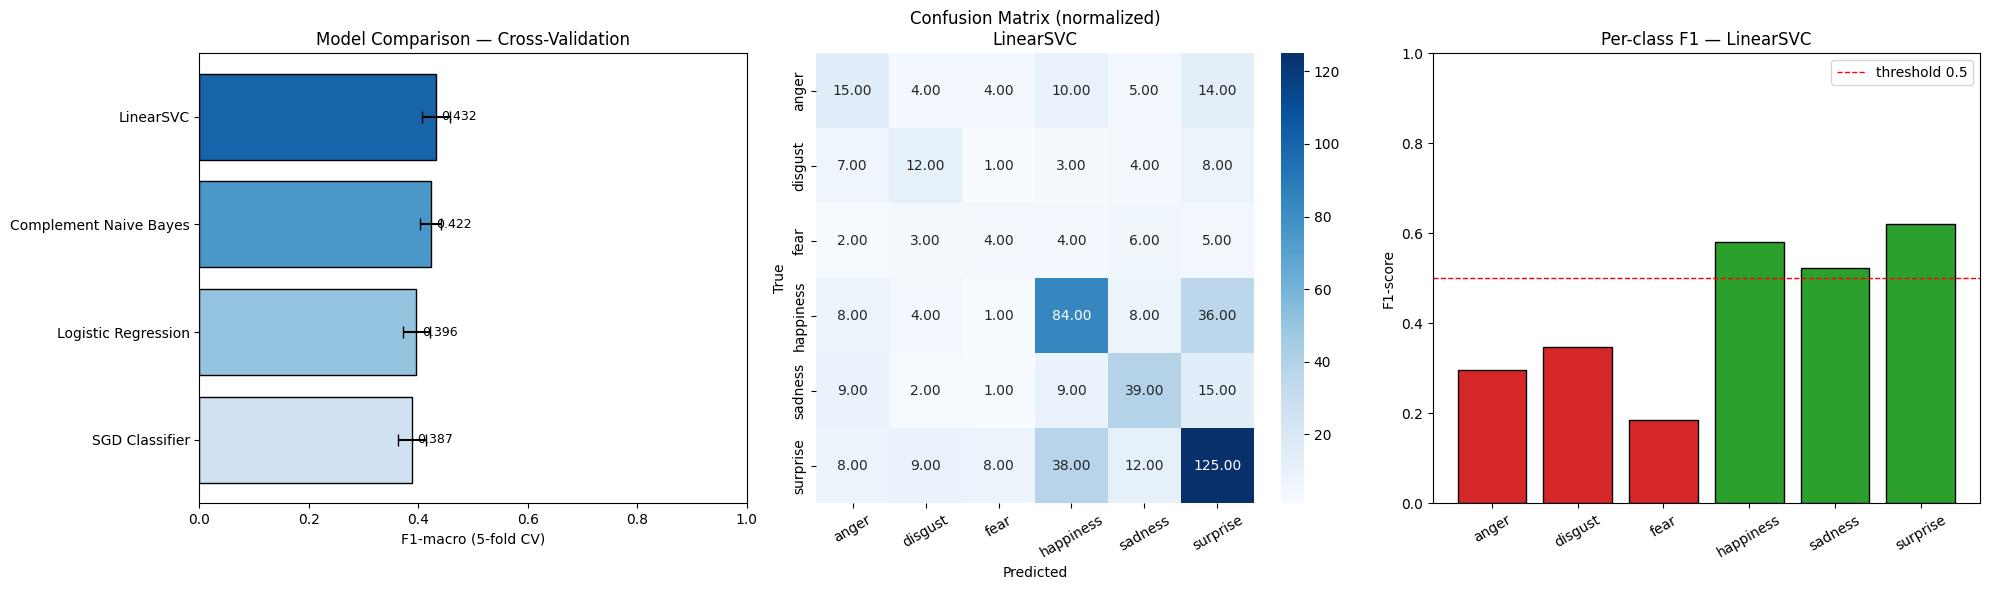

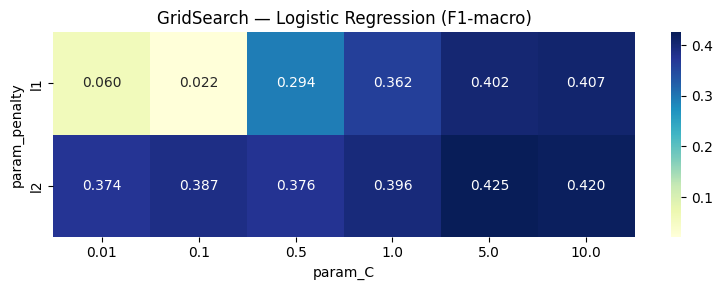

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
ax = axes[0]
bars = ax.barh(cv_df["Model"], cv_df["F1-macro"],
               xerr=cv_df["F1-macro std"],
               color=sns.color_palette("Blues_r", len(cv_df)),
               edgecolor="black", capsize=4)
ax.set_xlabel("F1-macro (5-fold CV)")
ax.set_title("Model Comparison — Cross-Validation")
ax.set_xlim(0, 1)
for bar, val in zip(bars, cv_df["F1-macro"]):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=9)
ax.invert_yaxis()

ax = axes[1]
#cm = confusion_matrix(y_test, y_pred_best, labels=EMOTIONS)
cm = confusion_matrix(y_test, y_pred_best, labels=list(range(len(EMOTIONS))))
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
#sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            #xticklabels=EMOTIONS, yticklabels=EMOTIONS, ax=ax)
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=EMOTIONS, yticklabels=EMOTIONS, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Confusion Matrix (normalized)\n{best_name}")
ax.tick_params(axis="x", rotation=30)

ax = axes[2]

report = classification_report(y_test, y_pred_best,
                                target_names=EMOTIONS, output_dict=True)
per_class_f1 = {e: report[e]["f1-score"] for e in EMOTIONS}
colors = ["#d62728" if v < 0.5 else "#2ca02c" for v in per_class_f1.values()]
ax.bar(per_class_f1.keys(), per_class_f1.values(), color=colors, edgecolor="black")
ax.axhline(0.5, color="red", linestyle="--", linewidth=1, label="threshold 0.5")
ax.set_ylim(0, 1)
ax.set_ylabel("F1-score")
ax.set_title(f"Per-class F1 — {best_name}")
ax.tick_params(axis="x", rotation=30)
ax.legend()

plt.tight_layout()
plt.savefig("emotion_baseline_results.png", dpi=150, bbox_inches="tight")
plt.show()

gs_results = pd.DataFrame(gs_lr.cv_results_)
pivot = gs_results.pivot_table(
    index="param_penalty",
    columns="param_C",
    values="mean_test_score"
)

plt.figure(figsize=(8, 3))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGnBu")
plt.title("GridSearch — Logistic Regression (F1-macro)")
plt.tight_layout()
plt.savefig("gridsearch_logreg.png", dpi=150)
plt.show()

In [ ]:
def show_top_features(model, n=10):
    feature_names = np.array(
        word_tfidf.get_feature_names_out().tolist() +
        char_tfidf.get_feature_names_out().tolist()
    )
    classes = model.classes_ if hasattr(model, "classes_") else EMOTIONS
    print(f"\nTop-{n} features per class")
    for i, cls in enumerate(classes):        
        coef    = model.coef_[i]
        top_idx = coef.argsort()[-n:][::-1]
        emotion = EMOTIONS[i] 
        print(f"\n  [{emotion.upper()}]: {', '.join(feature_names[top_idx])}")

show_top_features(gs_lr.best_estimator_)
print("\nDone. Figures saved: emotion_baseline_results.png, gridsearch_logreg.png")


=== Top-10 features per class ===

  [ANGER]: offense, fuck, stopping, cold, charged, fake, mad, fucking, rule, tony

  [DISGUST]: worst, shit, awful,  wors, wors, worse, ors, bad, nfl, pathetic

  [FEAR]: scary, billsmafia, grave, threat, nearly, real, concerned, pushing, win afc,  scar

  [HAPPINESS]: happy, love, fun, great, see, wait, cool, went super, practice, good

  [SADNESS]: sad, died, lost, los, retire, rip,  los, house visit, miss, ed 

  [SURPRISE]: wow, breaking, top, qb, since, best, top,  top, best wide, thought

Done. Figures saved: emotion_baseline_results.png, gridsearch_logreg.png
